<a href="https://colab.research.google.com/github/GBharathG/Heart-Health-EDA/blob/main/Pulse_of_Prevention_Heart_Health_EDA_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pulse of Prevention — Heart Health Data Analysis


**Company:** HealthPulse Analytics

**Objective:** Analyze patient heart-health data to understand demographic and clinical patterns, identify factors associated with heart disease, profile higher-risk groups, and support preventive decision-making.



## 1. Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from IPython.display import display
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


## 2. Upload the Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))

print("Uploaded file:", file_name)


Saving heart.csv to heart.csv
Uploaded file: heart.csv


## 3. Load the Dataset

In [ ]:
data = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

display(data.head())


Dataset loaded successfully.
Rows: 1025
Columns: 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 4. Initial Data Inspection

In [ ]:
print("Shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())

print("\nData types:")
display(data.dtypes.to_frame("Data Type"))

print("\nSummary statistics:")
display(data.describe().T)


Shape: (1025, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:


,Data Type
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


## 5. Check Missing Values

In [ ]:
missing = pd.DataFrame({
    "Missing Values": data.isna().sum(),
    "Missing %": (data.isna().mean() * 100).round(2)
}).sort_values("Missing Values", ascending=False)

display(missing)


,Missing Values,Missing %
age,0,0.0
sex,0,0.0
cp,0,0.0
trestbps,0,0.0
chol,0,0.0
fbs,0,0.0
restecg,0,0.0
thalach,0,0.0
exang,0,0.0
oldpeak,0,0.0


## 6. Check Duplicate Rows

In [ ]:
duplicate_count = data.duplicated().sum()
print("Duplicate rows:", duplicate_count)


Duplicate rows: 723


## 7. Check Unique Values and Data Quality

In [ ]:
for col in data.columns:
    print(f"\n{col}:")
    print("Unique values:", sorted(data[col].dropna().unique().tolist())[:30])
    print("Number of unique values:", data[col].nunique())



age:
Unique values: [29, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]
Number of unique values: 41

sex:
Unique values: [0, 1]
Number of unique values: 2

cp:
Unique values: [0, 1, 2, 3]
Number of unique values: 4

trestbps:
Unique values: [94, 100, 101, 102, 104, 105, 106, 108, 110, 112, 114, 115, 117, 118, 120, 122, 123, 124, 125, 126, 128, 129, 130, 132, 134, 135, 136, 138, 140, 142]
Number of unique values: 49

chol:
Unique values: [126, 131, 141, 149, 157, 160, 164, 166, 167, 168, 169, 172, 174, 175, 176, 177, 178, 180, 182, 183, 184, 185, 186, 187, 188, 192, 193, 195, 196, 197]
Number of unique values: 152

fbs:
Unique values: [0, 1]
Number of unique values: 2

restecg:
Unique values: [0, 1, 2]
Number of unique values: 3

thalach:
Unique values: [71, 88, 90, 95, 96, 97, 99, 103, 105, 106, 108, 109, 111, 112, 113, 114, 115, 116, 117, 118, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129]
Number of unique values

## 8. Data Cleaning and Preprocessing

In [ ]:
cleaned_data = data.copy()

# Ensure numeric columns are numeric
numeric_cols = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

for col in numeric_cols:
    cleaned_data[col] = pd.to_numeric(cleaned_data[col], errors="coerce")

# Remove rows with missing values if any are present
before = len(cleaned_data)
cleaned_data = cleaned_data.dropna().reset_index(drop=True)
removed_missing = before - len(cleaned_data)

# Remove exact duplicates
before_dup = len(cleaned_data)
cleaned_data = cleaned_data.drop_duplicates().reset_index(drop=True)
removed_duplicates = before_dup - len(cleaned_data)

print("Rows removed due to missing values:", removed_missing)
print("Duplicate rows removed:", removed_duplicates)
print("Final rows:", len(cleaned_data))


Rows removed due to missing values: 0
Duplicate rows removed: 723
Final rows: 302


## 9. Outlier Detection — Clinical Measurements

In [ ]:
clinical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

outlier_summary = []

for col in clinical_cols:
    q1 = cleaned_data[col].quantile(0.25)
    q3 = cleaned_data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((cleaned_data[col] < lower) | (cleaned_data[col] > upper)).sum()
    outlier_summary.append([col, q1, q3, lower, upper, int(count)])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature","Q1","Q3","Lower Bound","Upper Bound","Outlier Count"]
)

display(outlier_df)

# Keep clinical observations for analysis rather than deleting valid medical extremes automatically.
print("Note: Potential outliers are identified but not automatically removed because extreme clinical values can be meaningful observations.")


,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,age,48.00,61.00,28.500,80.500,0
1,trestbps,120.00,140.00,90.000,170.000,9
2,chol,211.00,274.75,115.375,370.375,5
3,thalach,133.25,166.00,84.125,215.125,1
4,oldpeak,0.00,1.60,-2.400,4.000,5


Note: Potential outliers are identified but not automatically removed because extreme clinical values can be meaningful observations.


## 10. Normalized Clinical Measurements

In [ ]:
# Standardized versions for multivariate analysis/modeling.
normalized_data = cleaned_data.copy()

for col in ["trestbps", "chol", "thalach", "oldpeak"]:
    mean = normalized_data[col].mean()
    std = normalized_data[col].std()
    normalized_data[col + "_z"] = (normalized_data[col] - mean) / std

display(normalized_data.head())


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,trestbps_z,chol_z,thalach_z,oldpeak_z
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,-0.375932,-0.666622,0.804700,-0.037063
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,0.478117,-0.840523,0.237102,1.771019
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,0.762800,-1.400872,-1.072740,1.340523
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,0.933609,-0.840523,0.499070,-0.898054
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,0.364243,0.917813,-1.902307,0.737829


## 11. Save Cleaned Dataset

In [ ]:
cleaned_file = "heart_health_cleaned.csv"
cleaned_data.to_csv(cleaned_file, index=False)

print("Saved:", cleaned_file)


Saved: heart_health_cleaned.csv


# BASIC LEVEL QUESTIONS


## Basic 1 — What is the average age of patients in the dataset?

In [ ]:
avg_age = cleaned_data["age"].mean()
print(f"Average patient age: {avg_age:.2f} years")


Average patient age: 54.42 years


## Basic 2 — What is the gender distribution of patients?

,Patients
sex,
Male,206
Female,96


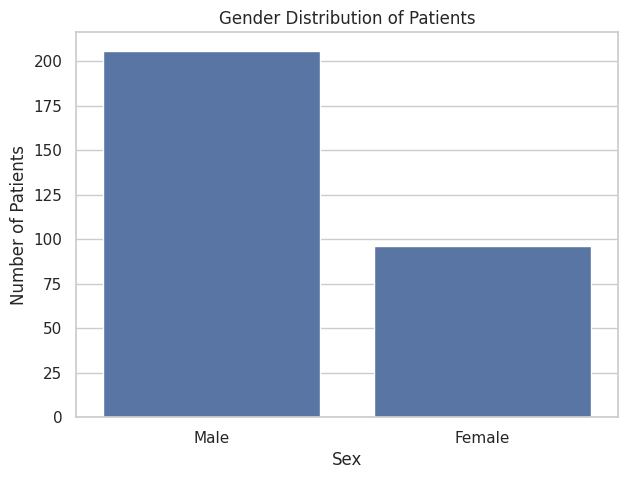

In [ ]:
gender_distribution = cleaned_data["sex"].map({
    1: "Male",
    0: "Female"
}).value_counts()

display(gender_distribution.to_frame("Patients"))

plt.figure(figsize=(7,5))
sns.barplot(x=gender_distribution.index, y=gender_distribution.values)
plt.title("Gender Distribution of Patients")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")
plt.show()


## Basic 3 — What is the average resting blood pressure of patients?

In [ ]:
avg_trestbps = cleaned_data["trestbps"].mean()
print(f"Average resting blood pressure: {avg_trestbps:.2f} mm Hg")


Average resting blood pressure: 131.60 mm Hg


## Basic 4 — How many patients have fasting blood sugar levels higher than 120 mg/dl?

In [ ]:
high_fbs_count = cleaned_data["fbs"].sum()
high_fbs_pct = cleaned_data["fbs"].mean() * 100

print("Patients with fasting blood sugar > 120 mg/dl:", int(high_fbs_count))
print(f"Percentage of patients: {high_fbs_pct:.2f}%")


Patients with fasting blood sugar > 120 mg/dl: 45
Percentage of patients: 14.90%


## Basic 5 — What are the different types of chest pain recorded?

In [ ]:
cp_values = sorted(cleaned_data["cp"].unique())
print("Chest pain types recorded:", cp_values)

cp_distribution = cleaned_data["cp"].value_counts().sort_index()
display(cp_distribution.to_frame("Patients"))


Chest pain types recorded: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


,Patients
cp,
0,143
1,50
2,86
3,23


## Basic 6 — What is the maximum heart rate achieved by patients?

In [ ]:
max_thalach = cleaned_data["thalach"].max()
print(f"Maximum heart rate achieved: {max_thalach} bpm")


Maximum heart rate achieved: 202 bpm


## Basic 7 — What percentage of patients experience exercise-induced angina?

In [ ]:
exang_pct = cleaned_data["exang"].mean() * 100
print(f"Patients experiencing exercise-induced angina: {exang_pct:.2f}%")


Patients experiencing exercise-induced angina: 32.78%


## Basic 8 — What is the average cholesterol level in the dataset?

In [ ]:
avg_chol = cleaned_data["chol"].mean()
print(f"Average cholesterol level: {avg_chol:.2f} mg/dl")


Average cholesterol level: 246.50 mg/dl


## Basic 9 — How many patients have a resting ECG result of 2?

In [ ]:
restecg_2_count = (cleaned_data["restecg"] == 2).sum()
print("Patients with resting ECG result of 2:", int(restecg_2_count))


Patients with resting ECG result of 2: 4


## Basic 10 — What is the distribution of the number of major vessels colored by fluoroscopy?

,Patients
ca,
0,175
1,65
2,38
3,20
4,4


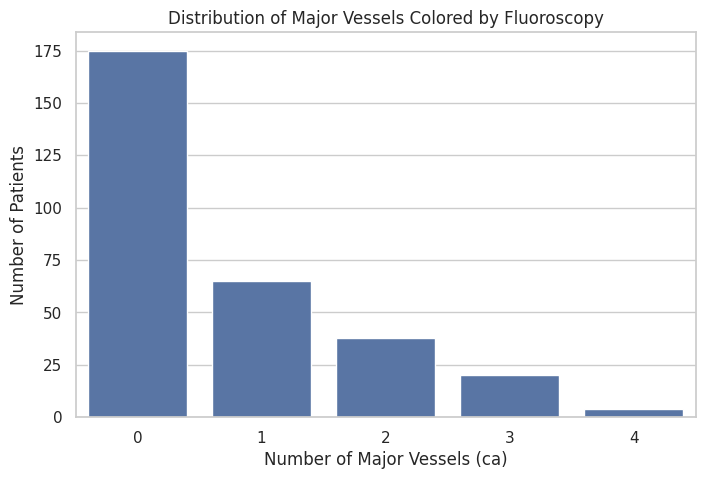

In [ ]:
ca_distribution = cleaned_data["ca"].value_counts().sort_index()

display(ca_distribution.to_frame("Patients"))

plt.figure(figsize=(8,5))
sns.barplot(x=ca_distribution.index.astype(str), y=ca_distribution.values)
plt.title("Distribution of Major Vessels Colored by Fluoroscopy")
plt.xlabel("Number of Major Vessels (ca)")
plt.ylabel("Number of Patients")
plt.show()


# MEDIUM LEVEL QUESTIONS


## Medium 1 — What is the correlation between age and cholesterol levels?

,age,chol
age,1.000000,0.207216
chol,0.207216,1.000000


Pearson correlation between age and cholesterol: 0.207


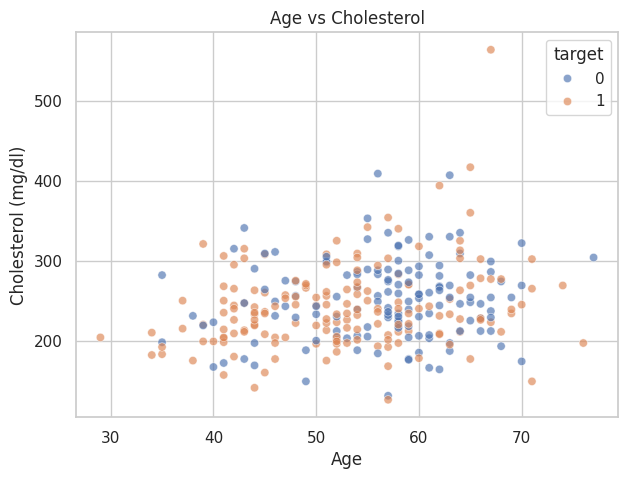

In [ ]:
age_chol_corr = cleaned_data[["age", "chol"]].corr()

display(age_chol_corr)

print(f"Pearson correlation between age and cholesterol: {cleaned_data['age'].corr(cleaned_data['chol']):.3f}")

plt.figure(figsize=(7,5))
sns.scatterplot(data=cleaned_data, x="age", y="chol", hue="target", alpha=0.65)
plt.title("Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol (mg/dl)")
plt.show()


## Medium 2 — What is the distribution of chest pain types across different age groups?

cp,0,1,2,3
age,,,,
29,0,1,0,0
34,0,1,0,1
35,3,1,0,0
37,0,0,2,0
38,0,0,1,1
39,1,0,3,0
40,2,0,0,1
41,1,6,3,0
42,3,1,3,1


cp,0,1,2,3
age_group,,,,
<40,4,3,6,2
40–49,28,19,22,3
50–59,61,21,34,9
60–69,46,4,21,9
70+,4,3,3,0


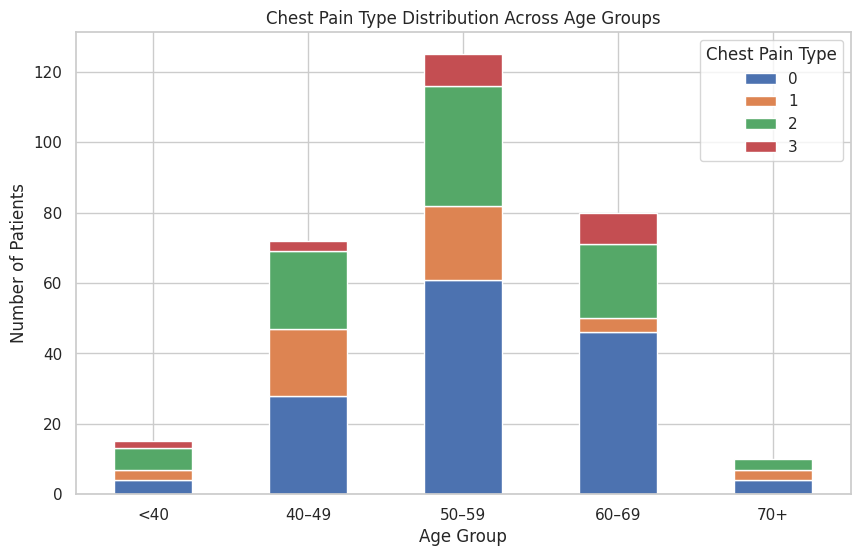

In [ ]:
age_cp = cleaned_data.groupby("age")["cp"].value_counts().unstack(fill_value=0)

display(age_cp.head(20))

# Use age bands for a clearer overall comparison
bins = [0, 39, 49, 59, 69, 100]
labels = ["<40", "40–49", "50–59", "60–69", "70+"]

temp = cleaned_data.copy()
temp["age_group"] = pd.cut(temp["age"], bins=bins, labels=labels)

age_group_cp = pd.crosstab(temp["age_group"], temp["cp"])
display(age_group_cp)

age_group_cp.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Chest Pain Type Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(title="Chest Pain Type")
plt.show()


## Medium 3 — How does maximum heart rate vary with exercise-induced angina?

,Average Maximum Heart Rate
exang,
0,155.596059
1,137.212121



0 = No exercise-induced angina; 1 = Yes
Without angina: 155.60 bpm
With angina: 137.21 bpm


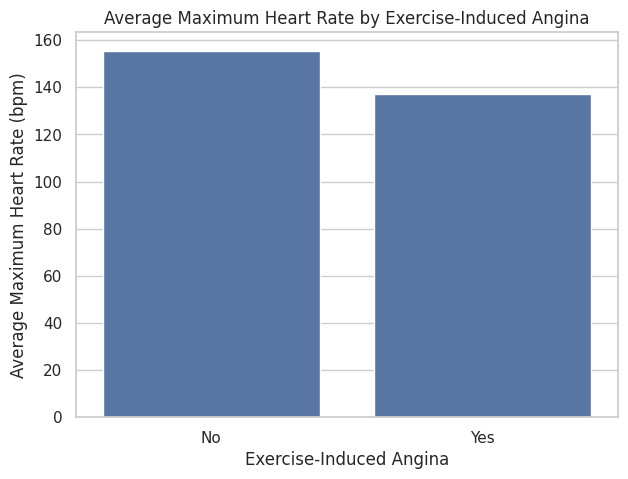

In [ ]:
thalach_exang = cleaned_data.groupby("exang")["thalach"].mean()

display(thalach_exang.to_frame("Average Maximum Heart Rate"))

print("\n0 = No exercise-induced angina; 1 = Yes")
print(f"Without angina: {thalach_exang.loc[0]:.2f} bpm")
print(f"With angina: {thalach_exang.loc[1]:.2f} bpm")

plt.figure(figsize=(7,5))
sns.barplot(x=thalach_exang.index.map({0:"No",1:"Yes"}), y=thalach_exang.values)
plt.title("Average Maximum Heart Rate by Exercise-Induced Angina")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Average Maximum Heart Rate (bpm)")
plt.show()


## Medium 4 — Is there a significant difference in resting blood pressure between male and female patients?

In [ ]:
male_bp = cleaned_data.loc[cleaned_data["sex"] == 1, "trestbps"]
female_bp = cleaned_data.loc[cleaned_data["sex"] == 0, "trestbps"]

male_mean = male_bp.mean()
female_mean = female_bp.mean()

t_stat, p_value = ttest_ind(male_bp, female_bp, equal_var=False)

print(f"Average resting BP — Male: {male_mean:.2f} mm Hg")
print(f"Average resting BP — Female: {female_mean:.2f} mm Hg")
print(f"Welch t-test statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: The difference is statistically significant at the 5% level.")
else:
    print("Result: The difference is not statistically significant at the 5% level.")


Average resting BP — Male: 130.91 mm Hg
Average resting BP — Female: 133.08 mm Hg
Welch t-test statistic: -0.949
P-value: 0.3443
Result: The difference is not statistically significant at the 5% level.


## Medium 5 — What is the relationship between fasting blood sugar levels and the presence of heart disease?

Counts:


target,0,1
fbs,,
0,116,141
1,22,23


Row percentages:


target,0,1
fbs,,
0,45.136187,54.863813
1,48.888889,51.111111


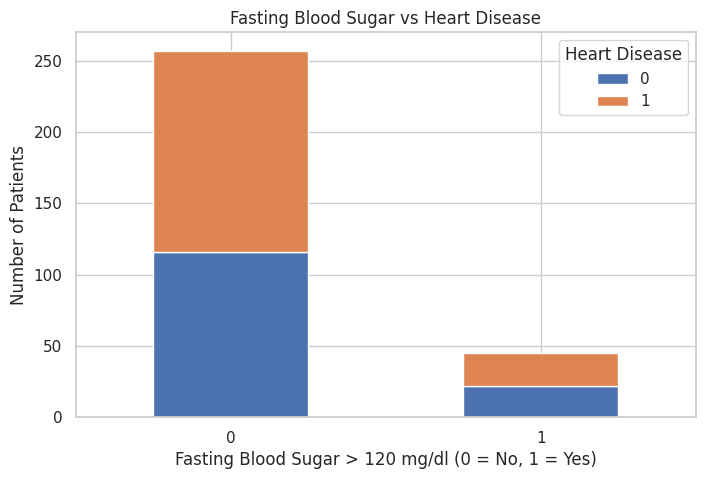

In [ ]:
fbs_target = pd.crosstab(
    cleaned_data["fbs"],
    cleaned_data["target"],
    normalize="index"
) * 100

fbs_counts = pd.crosstab(cleaned_data["fbs"], cleaned_data["target"])

print("Counts:")
display(fbs_counts)

print("Row percentages:")
display(fbs_target)

fbs_counts.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Fasting Blood Sugar vs Heart Disease")
plt.xlabel("Fasting Blood Sugar > 120 mg/dl (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(title="Heart Disease")
plt.show()


## Medium 6 — How does the number of major vessels (ca) affect the target variable?

target,0,1
ca,,
0,45,130
1,44,21
2,31,7
3,17,3
4,1,3


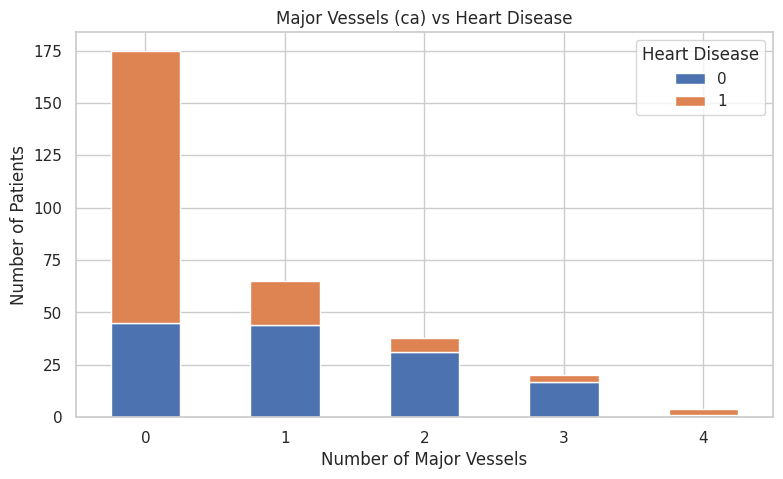

,Heart Disease Rate (%)
ca,
0,74.285714
1,32.307692
2,18.421053
3,15.000000
4,75.000000


In [ ]:
ca_target = pd.crosstab(
    cleaned_data["ca"],
    cleaned_data["target"]
)

display(ca_target)

ca_target.plot(kind="bar", stacked=True, figsize=(9,5))
plt.title("Major Vessels (ca) vs Heart Disease")
plt.xlabel("Number of Major Vessels")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(title="Heart Disease")
plt.show()

ca_rate = cleaned_data.groupby("ca")["target"].mean().mul(100)
display(ca_rate.to_frame("Heart Disease Rate (%)"))


## Medium 7 — What is the average oldpeak value for patients with different types of chest pain?

,Average Oldpeak
cp,
0,1.383217
1,0.316000
2,0.806977
3,1.391304


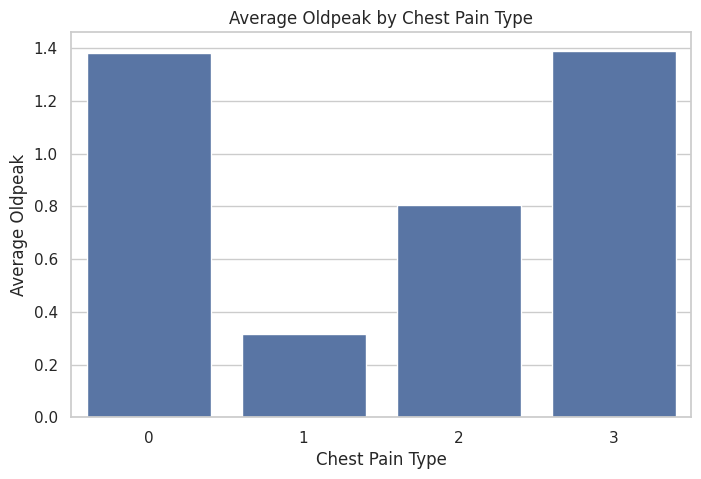

In [ ]:
oldpeak_cp = cleaned_data.groupby("cp")["oldpeak"].mean()

display(oldpeak_cp.to_frame("Average Oldpeak"))

plt.figure(figsize=(8,5))
sns.barplot(x=oldpeak_cp.index.astype(str), y=oldpeak_cp.values)
plt.title("Average Oldpeak by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Average Oldpeak")
plt.show()


## Medium 8 — Analyze the distribution of thalassemia types among patients with heart disease.

target,0,1
thal,,
0,1,1
1,12,6
2,36,129
3,89,28


,Heart Disease Patients
thal,
0,1
1,6
2,129
3,28


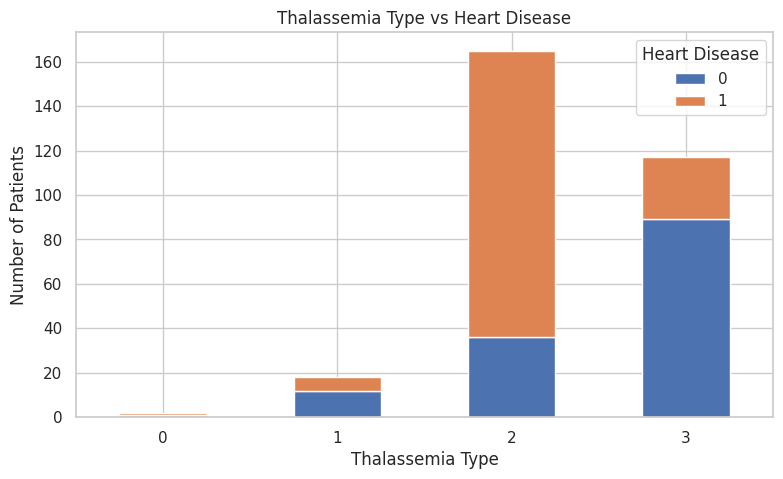

In [ ]:
thal_target = pd.crosstab(
    cleaned_data["thal"],
    cleaned_data["target"]
)

display(thal_target)

heart_patients_thal = cleaned_data.loc[cleaned_data["target"] == 1, "thal"].value_counts().sort_index()
display(heart_patients_thal.to_frame("Heart Disease Patients"))

thal_target.plot(kind="bar", stacked=True, figsize=(9,5))
plt.title("Thalassemia Type vs Heart Disease")
plt.xlabel("Thalassemia Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(title="Heart Disease")
plt.show()


## Medium 9 — What are the most common combinations of risk factors in patients with heart disease?

In [ ]:
heart_data = cleaned_data[cleaned_data["target"] == 1].copy()

risk_combinations = (
    heart_data.groupby(["cp", "fbs", "exang", "thal"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(risk_combinations.head(15))


,cp,fbs,exang,thal,count
15,2,0,0,2,41
8,1,0,0,2,30
1,0,0,0,2,23
19,2,1,0,2,10
4,0,0,1,2,6
16,2,0,0,3,6
23,3,0,0,2,5
9,1,0,0,3,4
17,2,0,1,2,4
20,2,1,0,3,3


## Medium 10 — Pairwise comparison of clinical measurements for patients with and without heart disease

age                     trestbps                          chol  \
             mean median       std        mean median        std        mean   
target                                                                         
0       56.601449   58.0  7.962082  134.398551  130.0  18.729944  251.086957   
1       52.585366   52.0  9.511957  129.250000  130.0  16.204739  242.640244   

                             thalach                     oldpeak         \
       median        std        mean median        std      mean median   
target                                                                    
0       249.0  49.454614  139.101449  142.0  22.598782  1.585507    1.4   
1       234.5  53.456580  158.378049  161.0  19.199080  0.586585    0.2   

                  
             std  
target            
0       1.300340  
1       0.781734

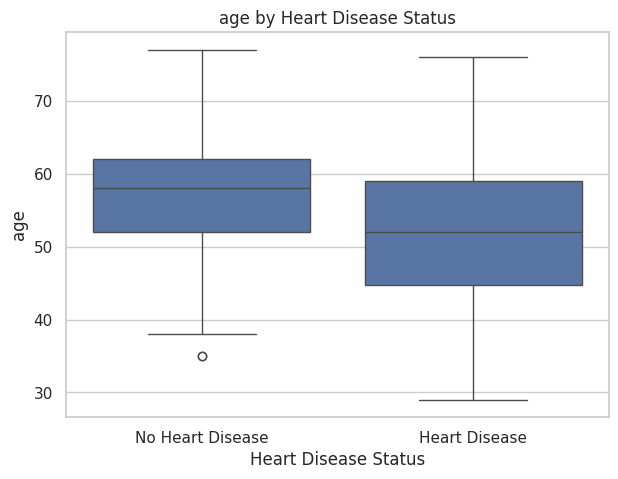

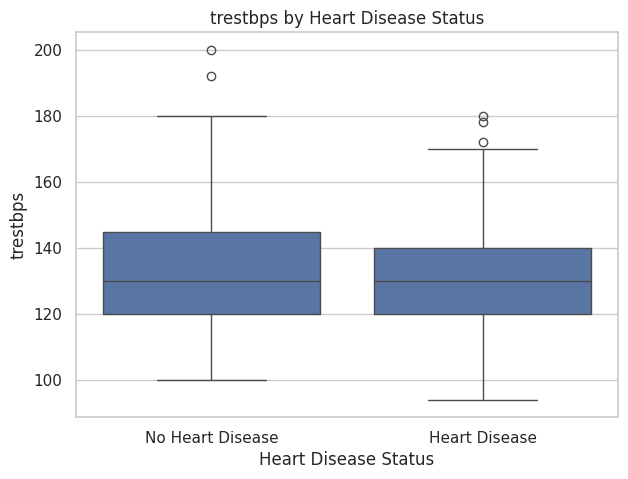

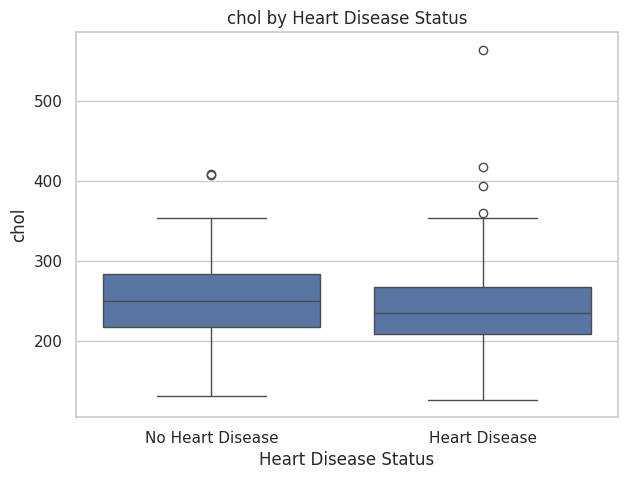

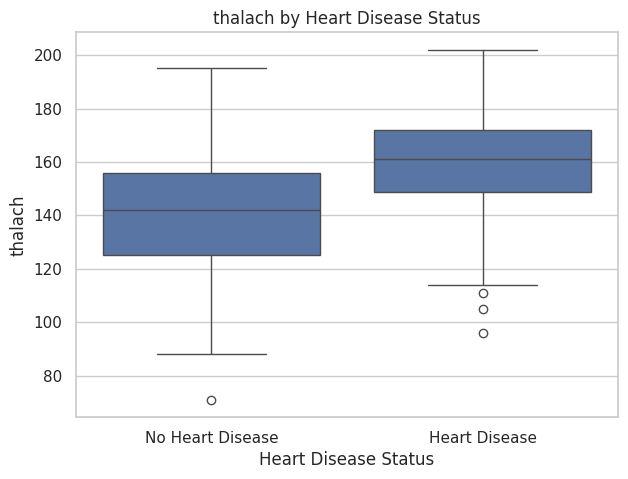

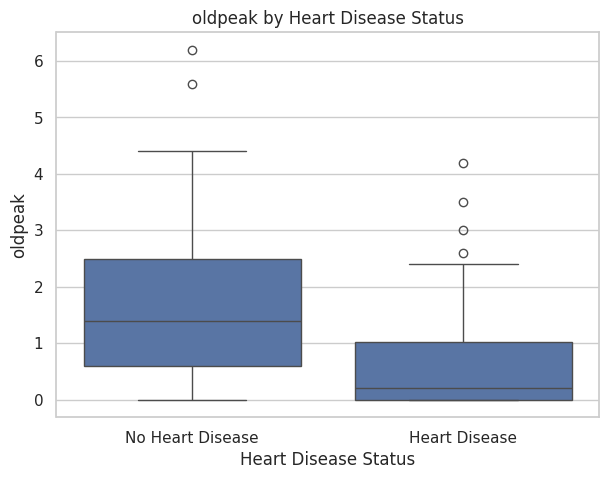

In [ ]:
clinical_compare = (
    cleaned_data.groupby("target")[["age", "trestbps", "chol", "thalach", "oldpeak"]]
    .agg(["mean", "median", "std"])
)

display(clinical_compare)

# Box plots for key continuous measurements
plot_data = cleaned_data[["target", "age", "trestbps", "chol", "thalach", "oldpeak"]].copy()
plot_data["target_label"] = plot_data["target"].map({0:"No Heart Disease", 1:"Heart Disease"})

for col in ["age", "trestbps", "chol", "thalach", "oldpeak"]:
    plt.figure(figsize=(7,5))
    sns.boxplot(data=plot_data, x="target_label", y=col)
    plt.title(f"{col} by Heart Disease Status")
    plt.xlabel("Heart Disease Status")
    plt.ylabel(col)
    plt.xticks(rotation=0)
    plt.show()


# ADVANCED LEVEL QUESTIONS

The document asks for five advanced analyses. The final item is handled carefully because the supplied dataset does not contain a time-to-event or survival outcome; therefore a true survival-rate analysis cannot be performed from these columns alone.

## Advanced 1 — Effect of Combining Age, Cholesterol, and Blood Pressure

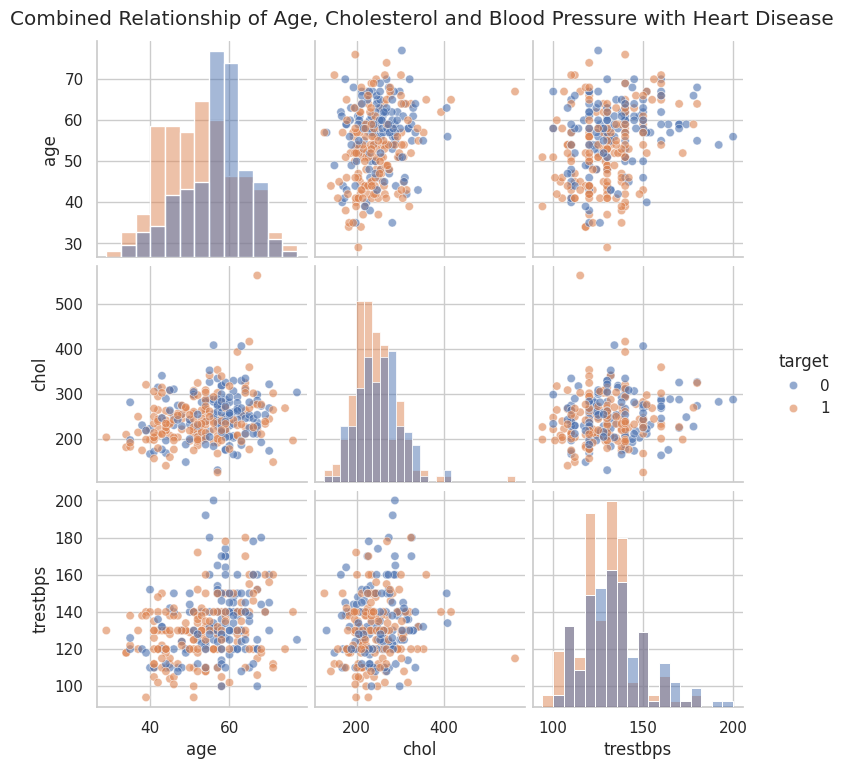

,count,mean,heart_disease_rate_pct
combined_factor_count,,,
0,50,0.640000,64.000000
1,88,0.681818,68.181818
2,111,0.495495,49.549550
3,53,0.320755,32.075472


In [ ]:
pair_cols = ["age", "chol", "trestbps", "target"]

sns.pairplot(
    cleaned_data[pair_cols],
    hue="target",
    diag_kind="hist",
    plot_kws={"alpha": 0.6}
)
plt.suptitle("Combined Relationship of Age, Cholesterol and Blood Pressure with Heart Disease", y=1.02)
plt.show()

# Group patients into a simple combined risk-factor profile for descriptive analysis
temp = cleaned_data.copy()

age_high = temp["age"] >= temp["age"].median()
chol_high = temp["chol"] >= temp["chol"].median()
bp_high = temp["trestbps"] >= temp["trestbps"].median()

temp["combined_factor_count"] = age_high.astype(int) + chol_high.astype(int) + bp_high.astype(int)

combined_risk = (
    temp.groupby("combined_factor_count")["target"]
    .agg(["count", "mean"])
)

combined_risk["heart_disease_rate_pct"] = combined_risk["mean"] * 100
display(combined_risk)


## Advanced 2 — Which Clinical Measurement Has the Strongest Correlation with Heart Disease?

,Correlation with Target
target,1.000000
cp,0.432080
thalach,0.419955
slope,0.343940
restecg,0.134874
fbs,-0.026826
chol,-0.081437
trestbps,-0.146269
age,-0.221476
sex,-0.283609


Strongest positive correlation with heart disease: cp (0.432)
Strongest negative correlation with heart disease: exang (-0.436)


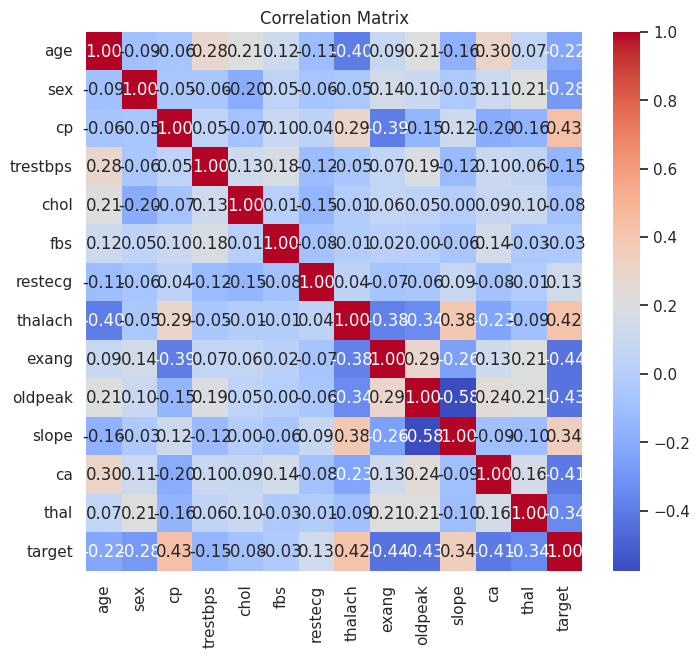

In [ ]:
corr_with_target = (
    cleaned_data.corr(numeric_only=True)["target"]
    .sort_values(ascending=False)
)

display(corr_with_target.to_frame("Correlation with Target"))

strongest_positive = corr_with_target.drop("target").idxmax()
strongest_negative = corr_with_target.drop("target").idxmin()

print("Strongest positive correlation with heart disease:", strongest_positive,
      f"({corr_with_target[strongest_positive]:.3f})")
print("Strongest negative correlation with heart disease:", strongest_negative,
      f"({corr_with_target[strongest_negative]:.3f})")

plt.figure(figsize=(8,7))
sns.heatmap(cleaned_data.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


## Advanced 3 — Logistic Regression to Predict Heart Disease Using Available Features

Accuracy: 0.803
ROC-AUC: 0.871

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,21,7
Actual 1,5,28


,Feature,Coefficient,Odds Ratio
2,cp,0.978893,2.661507
7,thalach,0.818189,2.266392
10,slope,0.309090,1.362185
6,restecg,0.224004,1.251076
0,age,0.087868,1.091844
5,fbs,-0.112431,0.893659
4,chol,-0.279967,0.755809
3,trestbps,-0.358746,0.698552
9,oldpeak,-0.400050,0.670287
8,exang,-0.499109,0.607072


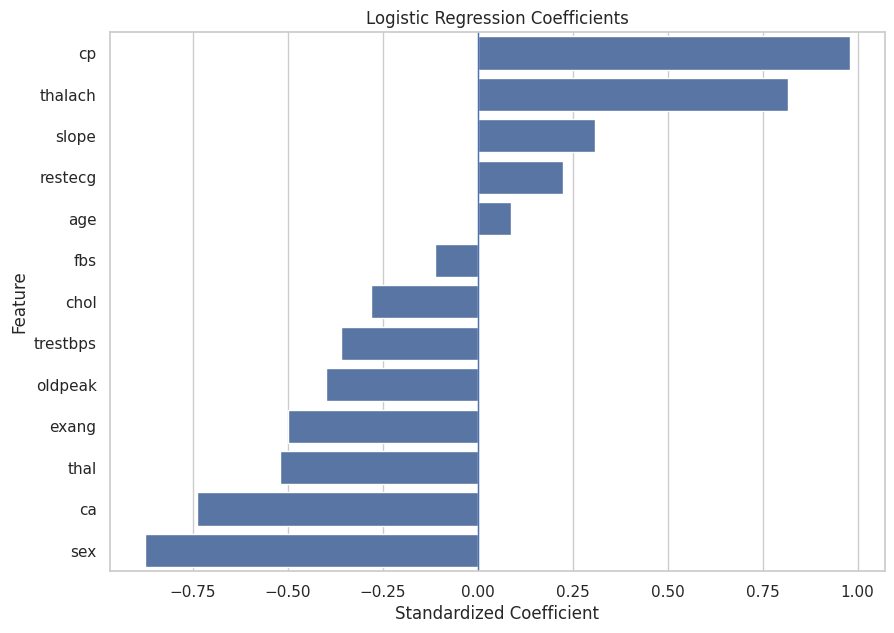

In [ ]:
features = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]

X = cleaned_data[features]
y = cleaned_data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

logistic_pipeline.fit(X_train, y_train)

pred = logistic_pipeline.predict(X_test)
prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, prob), 3))
print("\nClassification Report:")
print(classification_report(y_test, pred))

print("Confusion Matrix:")
display(pd.DataFrame(
    confusion_matrix(y_test, pred),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

coefficients = logistic_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients,
    "Odds Ratio": np.exp(coefficients)
}).sort_values("Coefficient", ascending=False)

display(coef_df)

plt.figure(figsize=(10,7))
sns.barplot(data=coef_df, x="Coefficient", y="Feature")
plt.axvline(0, linewidth=1)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")
plt.show()


## Advanced 4 — How do slope values vary with different chest pain types?

slope,0,1,2
cp,,,
0,11,84,48
1,2,12,36
2,5,33,48
3,3,11,9


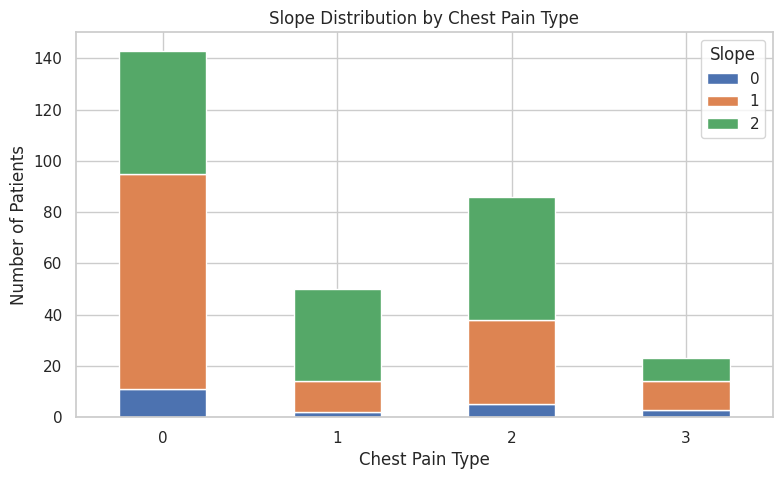

Average slope by chest pain type:


,Average Slope
cp,
0,1.258741
1,1.680000
2,1.500000
3,1.260870


In [ ]:
slope_cp = pd.crosstab(
    cleaned_data["cp"],
    cleaned_data["slope"]
)

display(slope_cp)

slope_cp.plot(kind="bar", stacked=True, figsize=(9,5))
plt.title("Slope Distribution by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(title="Slope")
plt.show()

print("Average slope by chest pain type:")
display(cleaned_data.groupby("cp")["slope"].mean().to_frame("Average Slope"))


## Advanced 5 — Thalassemia and 'Survival Rates' Over a Period

The supplied dataset does not contain a survival-time, follow-up-duration, or death/event date column.
Therefore, a true survival-rate-over-time analysis cannot be validly calculated from this dataset.

Available descriptive alternative:


,thal,target,count,mean
0,0,0,1,52.000000
1,0,1,1,53.000000
2,1,0,12,57.000000
3,1,1,6,56.000000
4,2,0,36,58.805556
5,2,1,129,51.813953
6,3,0,89,55.707865
7,3,1,28,55.392857


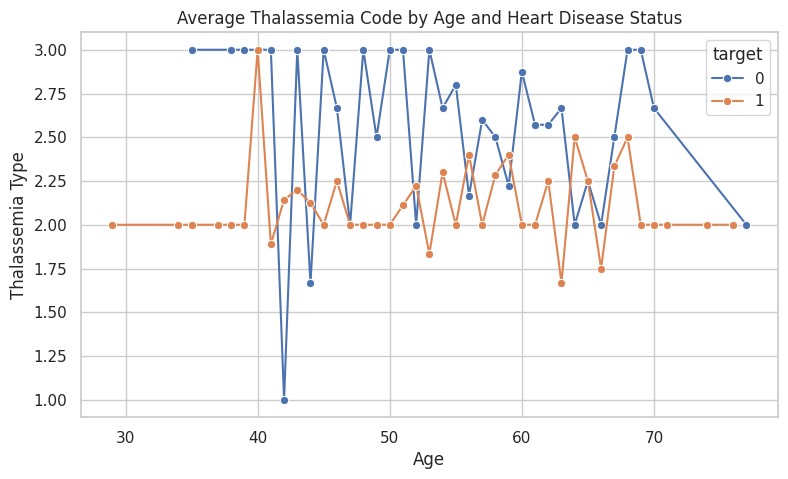


Interpretation: this is a descriptive age/thal/diagnosis view, NOT a survival analysis.


In [ ]:
print("The supplied dataset does not contain a survival-time, follow-up-duration, or death/event date column.")
print("Therefore, a true survival-rate-over-time analysis cannot be validly calculated from this dataset.")

print("\nAvailable descriptive alternative:")
thal_target_age = (
    cleaned_data.groupby(["thal", "target"])["age"]
    .agg(["count", "mean"])
    .reset_index()
)

display(thal_target_age)

plt.figure(figsize=(9,5))
sns.lineplot(
    data=cleaned_data,
    x="age",
    y="thal",
    hue="target",
    marker="o",
    estimator="mean",
    errorbar=None
)
plt.title("Average Thalassemia Code by Age and Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Thalassemia Type")
plt.show()

print("\nInterpretation: this is a descriptive age/thal/diagnosis view, NOT a survival analysis.")


# Key Findings Summary



In [ ]:
# Core results
heart_disease_rate = cleaned_data["target"].mean() * 100
male_pct = (cleaned_data["sex"] == 1).mean() * 100
female_pct = (cleaned_data["sex"] == 0).mean() * 100

top_cp = cleaned_data["cp"].value_counts().idxmax()
top_ca = cleaned_data["ca"].value_counts().idxmax()
top_thal = cleaned_data["thal"].value_counts().idxmax()

strongest_corr_feature = (
    corr_with_target.drop("target").abs().idxmax()
)
strongest_corr_value = corr_with_target[strongest_corr_feature]

print("===== PULSE OF PREVENTION — KEY RESULTS =====")
print(f"Total patients: {len(cleaned_data):,}")
print(f"Average age: {avg_age:.2f} years")
print(f"Male patients: {male_pct:.2f}%")
print(f"Female patients: {female_pct:.2f}%")
print(f"Average resting blood pressure: {avg_trestbps:.2f} mm Hg")
print(f"Average cholesterol: {avg_chol:.2f} mg/dl")
print(f"Heart disease prevalence in dataset: {heart_disease_rate:.2f}%")
print(f"Patients with fasting blood sugar >120 mg/dl: {high_fbs_count:,} ({high_fbs_pct:.2f}%)")
print(f"Exercise-induced angina: {exang_pct:.2f}%")
print(f"Maximum heart rate achieved: {max_thalach} bpm")
print(f"Most common chest pain type: {top_cp}")
print(f"Most common ca value: {top_ca}")
print(f"Most common thal value: {top_thal}")
print(f"Clinical variable with strongest absolute correlation with target: {strongest_corr_feature} ({strongest_corr_value:.3f})")


===== PULSE OF PREVENTION — KEY RESULTS =====
Total patients: 302
Average age: 54.42 years
Male patients: 68.21%
Female patients: 31.79%
Average resting blood pressure: 131.60 mm Hg
Average cholesterol: 246.50 mg/dl
Heart disease prevalence in dataset: 54.30%
Patients with fasting blood sugar >120 mg/dl: 45 (14.90%)
Exercise-induced angina: 32.78%
Maximum heart rate achieved: 202 bpm
Most common chest pain type: 0
Most common ca value: 0
Most common thal value: 2
Clinical variable with strongest absolute correlation with target: exang (-0.436)


# High-Risk Patient Profile — Descriptive

This section creates a **data-derived profile**, not a medical diagnosis.

In [ ]:
# Compare selected variables between patients with and without heart disease
profile = cleaned_data.groupby("target")[
    ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "exang"]
].mean()

profile.index = ["No Heart Disease", "Heart Disease"]
display(profile)

print("\nImportant: These are group-level patterns in this dataset and should not be interpreted as individual medical diagnoses.")


,age,trestbps,chol,thalach,oldpeak,ca,exang
No Heart Disease,56.601449,134.398551,251.086957,139.101449,1.585507,1.166667,0.550725
Heart Disease,52.585366,129.250000,242.640244,158.378049,0.586585,0.341463,0.140244



Important: These are group-level patterns in this dataset and should not be interpreted as individual medical diagnoses.


# Business / Healthcare Recommendations

### 1. Risk-factor monitoring
Prioritize monitoring of the clinical variables that show the strongest association with the target in the correlation and logistic-regression analyses.

### 2. High-risk profile identification
Use combinations of age, blood pressure, cholesterol, chest pain, exercise-induced angina, and other available clinical indicators to support risk-stratification workflows.

### 3. Preventive programs
Develop targeted preventive initiatives around the strongest observed risk patterns, while avoiding one-variable conclusions.

### 4. Clinical resource allocation
Use observed patterns in chest pain, major vessels, thalassemia type, and exercise response to help prioritize further clinical review.

### 5. Further research
The dataset is cross-sectional and does not include survival time or follow-up outcomes. Future studies should add longitudinal follow-up, treatment, and actual patient outcomes before making survival or causal claims.


## Final Conclusion

In [ ]:
print(
    "The analysis provides a structured view of patient demographics, clinical measurements, "
    "heart-disease patterns, and predictive relationships. These findings can support "
    "data-driven risk profiling and preventive planning, while clinical decisions should "
    "always be validated by qualified healthcare professionals."
)


The analysis provides a structured view of patient demographics, clinical measurements, heart-disease patterns, and predictive relationships. These findings can support data-driven risk profiling and preventive planning, while clinical decisions should always be validated by qualified healthcare professionals.


## Download the Cleaned Dataset

In [ ]:
from google.colab import files
files.download(cleaned_file)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>